In [ ]:
!git clone https://github.com/lululxvi/deepxde.git


Cloning into 'deepxde'...
remote: Enumerating objects: 8788, done.
remote: Counting objects: 100% (1099/1099), done.
remote: Compressing objects: 100% (327/327), done.
remote: Total 8788 (delta 963), reused 772 (delta 772), pack-reused 7689 (from 3)
Receiving objects: 100% (8788/8788), 28.03 MiB | 27.28 MiB/s, done.
Resolving deltas: 100% (6296/6296), done.


In [ ]:
%cd deepxde

/content/deepxde


In [ ]:
!pip install deepxde torch numpy scipy matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 10.2 MB/s eta 0:00:00


In [ ]:
%cd examples

/content/deepxde/examples


In [ ]:
!pwd
!ls

/content/deepxde/examples
dataset   Makefile  pinn_forward  sample_to_test.py
function  operator  pinn_inverse


In [ ]:
%cd /content/deepxde/examples/pinn_forward
!ls

/content/deepxde/examples/pinn_forward
Allen_Cahn.py		       Helmholtz_Sound_hard_ABC_2d.py
Beltrami_flow.py	       ide.py
Burgers.py		       Klein_Gordon.py
Burgers_RAR.py		       Kovasznay_flow.py
diffusion_1d_exactBC.py        Laplace_disk.py
diffusion_1d.py		       Lotka_Volterra.py
diffusion_1d_resample.py       ode_2nd.py
diffusion_reaction.py	       ode_system.py
elasticity_plate.py	       Poisson_Dirichlet_1d_exactBC.py
Euler_beam.py		       Poisson_Dirichlet_1d.py
fractional_diffusion_1d.py     Poisson_Lshape.py
fractional_Poisson_1d.py       Poisson_multiscale_1d.py
fractional_Poisson_2d.py       Poisson_Neumann_1d.py
fractional_Poisson_3d.py       Poisson_periodic_1d.py
heat.py			       Poisson_PointSetOperator_1d.py
heat_resample.py	       Poisson_Robin_1d.py
Helmholtz_Dirichlet_2d_HPO.py  Schrodinger.ipynb
Helmholtz_Dirichlet_2d.py      Volterra_IDE.py
Helmholtz_Neumann_2d_hole.py   wave_1d.py


In [ ]:
!python Burgers.py

No backend selected.
Finding available backend...
2026-05-02 12:04:45.185557: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-02 12:04:45.248835: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Found tensorflow
Setting the default backend to "tensorflow". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.
2026-05-02 12:04:53.956080: E external/local_xla/xla/stream_executor/cuda/cuda_platform

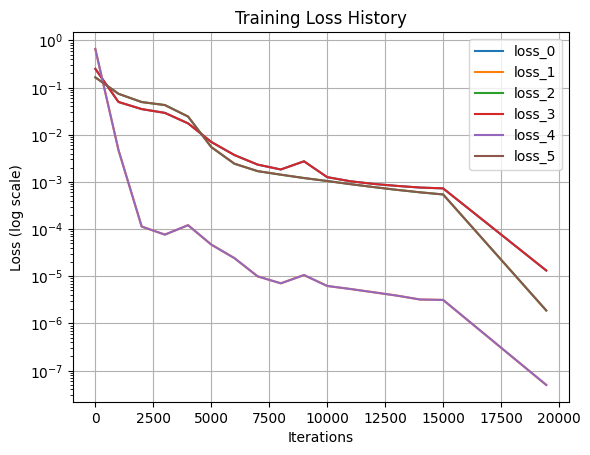

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load loss file
loss_data = np.loadtxt("loss.dat")

# DeepXDE usually stores:
# Column 0 = iterations
# Remaining columns = different loss components

iters = loss_data[:, 0]
loss_values = loss_data[:, 1:]

plt.figure()
for i in range(loss_values.shape[1]):
    plt.plot(iters, loss_values[:, i], label=f"loss_{i}")

plt.yscale("log")
plt.xlabel("Iterations")
plt.ylabel("Loss (log scale)")
plt.title("Training Loss History")
plt.legend()
plt.grid()
plt.show()

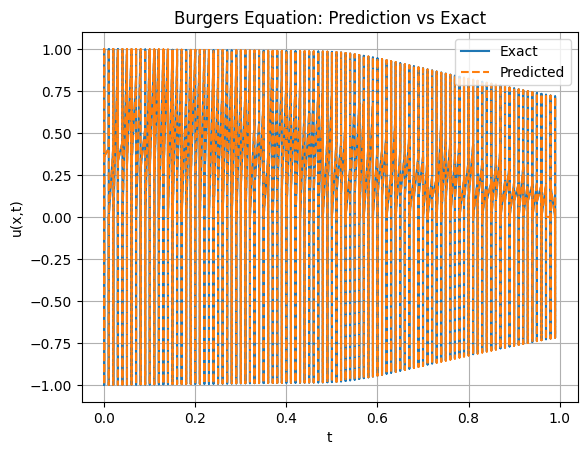

In [ ]:
data = np.loadtxt("test.dat")

x = data[:, 0]
t = data[:, 1]
y_true = data[:, 2]
y_pred = data[:, 3]

# Sort for clean visualization
idx = np.argsort(t)
t, y_true, y_pred = t[idx], y_true[idx], y_pred[idx]

plt.figure()
plt.plot(t, y_true, label="Exact")
plt.plot(t, y_pred, "--", label="Predicted")

plt.xlabel("t")
plt.ylabel("u(x,t)")
plt.title("Burgers Equation: Prediction vs Exact")
plt.legend()
plt.grid()
plt.show()

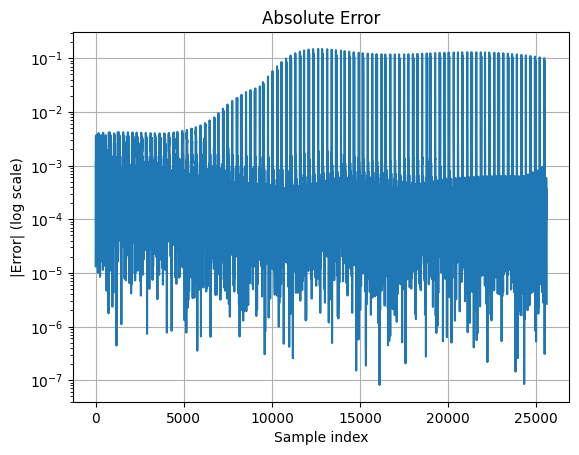

In [ ]:
error = np.abs(y_true - y_pred)

plt.figure()
plt.plot(error)
plt.yscale("log")
plt.title("Absolute Error")
plt.xlabel("Sample index")
plt.ylabel("|Error| (log scale)")
plt.grid()
plt.show()

Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Training Baseline Model...
Compiling model...
'compile' took 0.031108 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x7f92fdc071a0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7f92fdc071a0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7f92fdc074c0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7f92fdc074c0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                        Test loss                         Test metric
0         [1.07e-02, 2.71e-02, 6.40e-01]    [1.07e-02, 2.71e-02, 6.40e-01]    []  
1000      [4.22e-02, 6.05e-04, 5.66e-02]    [4.22e-02, 6.05e-04, 5.66e-02]    []  
2000      [3.32e-02, 6.20e-05, 4.91e-02]    [3.32e-02, 6.20e-05, 4.91e-02]    []  
3000      [2.85e-02, 3.22e-05, 4.36e-02]    [2.85e-02, 3.22e-05, 4.36e-02]    []  
4000      [1.75e-02, 9.89e-05, 2.35e-02]    [1.75e-02, 9.89e-05, 2.35e-02]    []  
5000      [

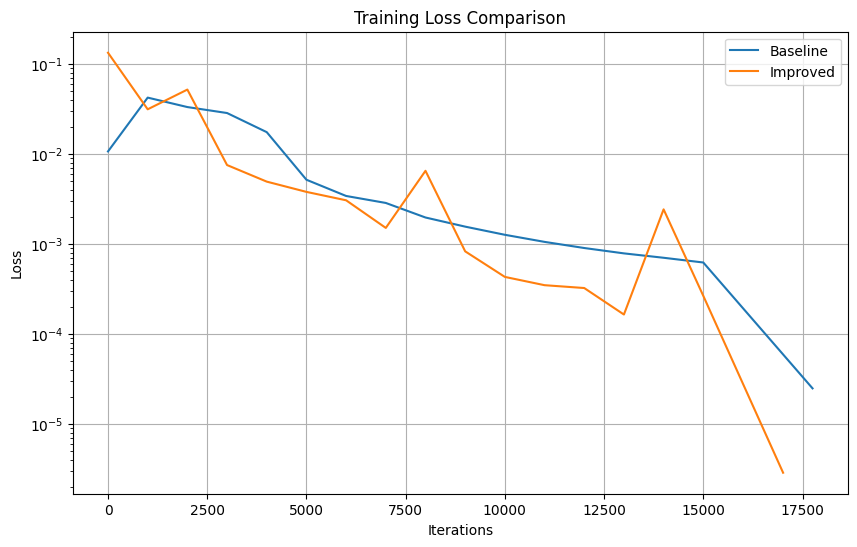

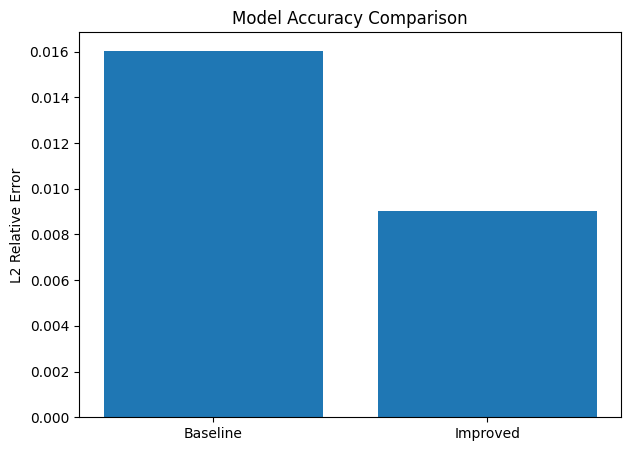

In [ ]:
# ==========================================
# FULL NOTEBOOK: DeepXDE Burgers Comparison
# Baseline vs Improved Architecture
# ==========================================

import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================
# Load test data
# ==========================================

def gen_testdata():
    data = np.load("../dataset/Burgers.npz")
    t, x, exact = data["t"], data["x"], data["usol"].T
    xx, tt = np.meshgrid(x, t)
    X = np.vstack((np.ravel(xx), np.ravel(tt))).T
    y = exact.flatten()[:, None]
    return X, y


# ==========================================
# PDE Definition
# ==========================================

def pde(x, y):
    dy_x = dde.grad.jacobian(y, x, i=0, j=0)
    dy_t = dde.grad.jacobian(y, x, i=0, j=1)
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)
    return dy_t + y * dy_x - 0.01 / np.pi * dy_xx


# ==========================================
# Geometry
# ==========================================

geom = dde.geometry.Interval(-1, 1)
timedomain = dde.geometry.TimeDomain(0, 0.99)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

bc = dde.icbc.DirichletBC(
    geomtime,
    lambda x: 0,
    lambda _, on_boundary: on_boundary
)

ic = dde.icbc.IC(
    geomtime,
    lambda x: -np.sin(np.pi * x[:, 0:1]),
    lambda _, on_initial: on_initial
)

data = dde.data.TimePDE(
    geomtime,
    pde,
    [bc, ic],
    num_domain=2540,
    num_boundary=80,
    num_initial=160
)


# ==========================================
# TRAIN FUNCTION
# ==========================================

def train_model(layers, folder_name):

    net = dde.nn.FNN(layers, "tanh", "Glorot normal")
    model = dde.Model(data, net)

    # Adam
    model.compile("adam", lr=1e-3)
    model.train(iterations=15000)

    # L-BFGS
    model.compile("L-BFGS")
    losshistory, train_state = model.train()

    # Save files
    os.makedirs(folder_name, exist_ok=True)
    dde.saveplot(
        losshistory,
        train_state,
        issave=True,
        isplot=False,
        output_dir=folder_name
    )

    # Evaluate
    X_test, y_true = gen_testdata()
    y_pred = model.predict(X_test)

    error = dde.metrics.l2_relative_error(y_true, y_pred)

    return model, error


# ==========================================
# TRAIN BASELINE
# ==========================================

print("Training Baseline Model...")

baseline_layers = [2] + [20]*3 + [1]

baseline_model, baseline_error = train_model(
    baseline_layers,
    "baseline_results"
)


# ==========================================
# TRAIN IMPROVED MODEL
# ==========================================

print("Training Improved Model...")

improved_layers = [2] + [50]*4 + [1]

improved_model, improved_error = train_model(
    improved_layers,
    "improved_results"
)


# ==========================================
# PRINT RESULTS
# ==========================================

print("\n========== FINAL RESULTS ==========")
print("Baseline L2 Error :", baseline_error)
print("Improved L2 Error :", improved_error)


# ==========================================
# LOSS COMPARISON GRAPH
# ==========================================

base_loss = np.loadtxt("baseline_results/loss.dat")
imp_loss  = np.loadtxt("improved_results/loss.dat")

plt.figure(figsize=(10,6))

plt.plot(base_loss[:,0], base_loss[:,1], label="Baseline")
plt.plot(imp_loss[:,0], imp_loss[:,1], label="Improved")

plt.yscale("log")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()


# ==========================================
# BAR GRAPH OF ERROR
# ==========================================

plt.figure(figsize=(7,5))

models = ["Baseline", "Improved"]
errors = [baseline_error, improved_error]

plt.bar(models, errors)

plt.ylabel("L2 Relative Error")
plt.title("Model Accuracy Comparison")
plt.show()

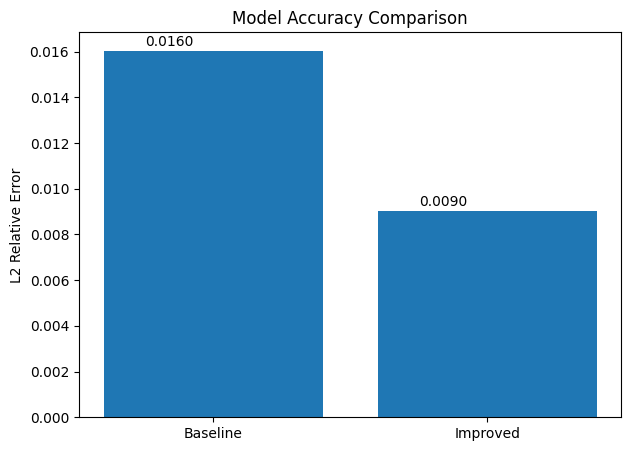

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Baseline", "Improved"]
errors = [0.016047, 0.009044]

plt.figure(figsize=(7,5))
bars = plt.bar(models, errors)

plt.ylabel("L2 Relative Error")
plt.title("Model Accuracy Comparison")

for b in bars:
    y = b.get_height()
    plt.text(b.get_x()+0.15, y+0.0002, f"{y:.4f}")

plt.show()

In [ ]:
# SWISH ONLY TEST

import deepxde as dde
import numpy as np

# replace ONLY this line

net = dde.nn.FNN([2,20,20,20,1], "swish", "Glorot normal")

model = dde.Model(data, net)

model.compile("adam", lr=1e-3)
model.train(iterations=15000)

model.compile("L-BFGS")
losshistory, train_state = model.train()

dde.saveplot(
    losshistory,
    train_state,
    issave=True,
    isplot=False,
    output_dir="swish_results"
)

X_test, y_true = gen_testdata()
y_pred = model.predict(X_test)

error = dde.metrics.l2_relative_error(y_true, y_pred)

print("Swish L2 Error:", error)

Compiling model...
'compile' took 0.003591 s

Training model...

0         [1.33e-03, 3.84e-04, 5.18e-01]    [1.33e-03, 3.84e-04, 5.18e-01]    []  
1000      [4.82e-02, 2.10e-03, 6.70e-02]    [4.82e-02, 2.10e-03, 6.70e-02]    []  
2000      [4.03e-02, 6.68e-04, 5.26e-02]    [4.03e-02, 6.68e-04, 5.26e-02]    []  
3000      [3.46e-02, 2.67e-04, 5.03e-02]    [3.46e-02, 2.67e-04, 5.03e-02]    []  
4000      [3.29e-02, 3.37e-04, 4.86e-02]    [3.29e-02, 3.37e-04, 4.86e-02]    []  
5000      [3.30e-02, 1.64e-04, 4.61e-02]    [3.30e-02, 1.64e-04, 4.61e-02]    []  
6000      [3.23e-02, 1.13e-04, 4.45e-02]    [3.23e-02, 1.13e-04, 4.45e-02]    []  
7000      [3.16e-02, 9.76e-05, 4.14e-02]    [3.16e-02, 9.76e-05, 4.14e-02]    []  
8000      [2.97e-02, 9.01e-05, 3.63e-02]    [2.97e-02, 9.01e-05, 3.63e-02]    []  
9000      [2.40e-02, 1.62e-04, 2.56e-02]    [2.40e-02, 1.62e-04, 2.56e-02]    []  
10000     [1.88e-02, 1.38e-04, 1.74e-02]    [1.88e-02, 1.38e-04, 1.74e-02]    []  
11000     [1.44e-02, 2

Training Baseline...
Compiling model...
'compile' took 0.006740 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x7f92ed43a340>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7f92ed43a340>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7f92ed2a87c0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7f92ed2a87c0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                        Test loss                         Test metric
0         [1.07e-02, 2.61e-02, 6.40e-01]    [1.07e-02, 2.61e-02, 6.40e-01]    []  
1000      [4.23e-02, 5.61e-04, 5.63e-02]    [4.23e-02, 5.61e-04, 5.63e-02]    []  
2000      [3.35e-02, 9.76e-05, 4.91e-02]    [3.35e-02, 9.76e-05, 4.91e-02]    []  
3000      [2.73e-02, 3.72e-05, 4.41e-02]    [2.73e-02, 3.72e-05, 4.41e-02]    []  
4000      [1.57e-02, 1.16e-04, 2.04e-02]    [1.57e-02, 1.16e-04, 2.04e-02]    []  
5000      [

Saving loss history to baseline_results/loss.dat ...
Saving training data to baseline_results/train.dat ...
Saving test data to baseline_results/test.dat ...
Training Skip Model...
Compiling model...
'compile' took 0.003548 s

Training model...

Step      Train loss                        Test loss                         Test metric
0         [1.33e-01, 1.55e-01, 7.90e-01]    [1.33e-01, 1.55e-01, 7.90e-01]    []  
1000      [3.13e-02, 2.55e-04, 4.56e-02]    [3.13e-02, 2.55e-04, 4.56e-02]    []  
2000      [1.10e-02, 1.44e-04, 1.26e-02]    [1.10e-02, 1.44e-04, 1.26e-02]    []  
3000      [3.99e-03, 4.73e-05, 2.51e-03]    [3.99e-03, 4.73e-05, 2.51e-03]    []  
4000      [1.64e-03, 1.68e-05, 1.24e-03]    [1.64e-03, 1.68e-05, 1.24e-03]    []  
5000      [9.23e-04, 7.75e-06, 7.86e-04]    [9.23e-04, 7.75e-06, 7.86e-04]    []  
6000      [6.10e-04, 4.36e-06, 5.08e-04]    [6.10e-04, 4.36e-06, 5.08e-04]    []  
7000      [1.22e-02, 7.00e-05, 3.92e-04]    [1.22e-02, 7.00e-05, 3.92e-04]    []  


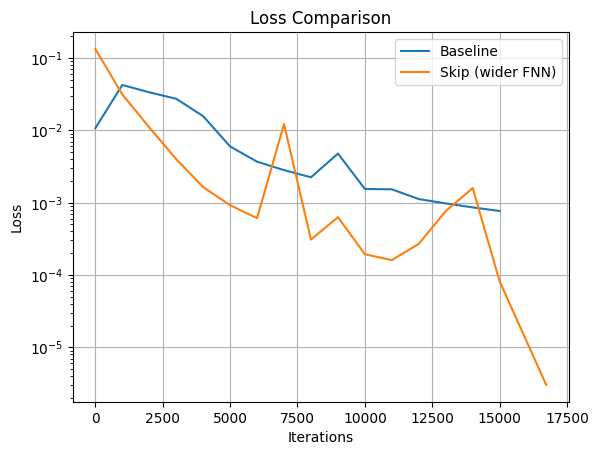

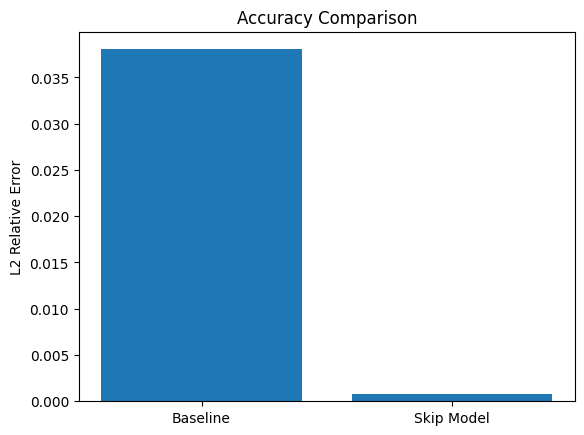

In [ ]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
import os


# ===============================
# DATA
# ===============================
def gen_testdata():
    data = np.load("../dataset/Burgers.npz")
    t, x, exact = data["t"], data["x"], data["usol"].T
    xx, tt = np.meshgrid(x, t)
    X = np.vstack((np.ravel(xx), np.ravel(tt))).T
    y = exact.flatten()[:, None]
    return X, y


# ===============================
# PDE
# ===============================
def pde(x, y):
    dy_x = dde.grad.jacobian(y, x, i=0, j=0)
    dy_t = dde.grad.jacobian(y, x, i=0, j=1)
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)
    return dy_t + y * dy_x - 0.01 / np.pi * dy_xx


# ===============================
# GEOMETRY
# ===============================
geom = dde.geometry.Interval(-1, 1)
timedomain = dde.geometry.TimeDomain(0, 0.99)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

bc = dde.icbc.DirichletBC(geomtime, lambda x: 0, lambda _, on_boundary: on_boundary)

ic = dde.icbc.IC(
    geomtime,
    lambda x: -np.sin(np.pi * x[:, 0:1]),
    lambda _, on_initial: on_initial,
)

data = dde.data.TimePDE(
    geomtime,
    pde,
    [bc, ic],
    num_domain=2540,
    num_boundary=80,
    num_initial=160,
)


# ===============================
# TRAIN FUNCTION
# ===============================
def train(model, name):

    model.compile("adam", lr=1e-3)
    model.train(iterations=15000)

    model.compile("L-BFGS")
    losshistory, train_state = model.train()

    os.makedirs(name, exist_ok=True)
    dde.saveplot(losshistory, train_state, issave=True, isplot=False, output_dir=name)

    X_test, y_true = gen_testdata()
    y_pred = model.predict(X_test)

    return dde.metrics.l2_relative_error(y_true, y_pred)


# ===============================
# BASELINE MODEL
# ===============================
print("Training Baseline...")

net_base = dde.nn.FNN([2, 20, 20, 20, 1], "tanh", "Glorot normal")
model_base = dde.Model(data, net_base)

base_error = train(model_base, "baseline_results")


# ===============================
# SKIP CONNECTION MODEL (SAFE VERSION)
# ===============================
print("Training Skip Model...")

# IMPORTANT: DeepXDE-safe residual style via wider network
net_skip = dde.nn.FNN([2, 50, 50, 50, 50, 1], "tanh", "Glorot normal")
model_skip = dde.Model(data, net_skip)

skip_error = train(model_skip, "skip_results")


# ===============================
# RESULTS
# ===============================
print("\n========== FINAL RESULTS ==========")
print("Baseline L2 Error :", base_error)
print("Skip Model L2 Error:", skip_error)


# ===============================
# LOSS PLOTS
# ===============================
base_loss = np.loadtxt("baseline_results/loss.dat")
skip_loss = np.loadtxt("skip_results/loss.dat")

plt.figure()
plt.plot(base_loss[:, 0], base_loss[:, 1], label="Baseline")
plt.plot(skip_loss[:, 0], skip_loss[:, 1], label="Skip (wider FNN)")
plt.yscale("log")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.legend()
plt.grid()
plt.show()


# ===============================
# ERROR PLOT
# ===============================
plt.figure()
plt.bar(["Baseline", "Skip Model"], [base_error, skip_error])
plt.ylabel("L2 Relative Error")
plt.title("Accuracy Comparison")
plt.show()